## Gaussian Process Regressor(GPR) on Supernovae measurments
In this exercise, our goal is to estimate the relationship between the magnitude and redshift of various supernovae using Gaussian Process Regression (GPR). According to the standard cosmological model, $\Lambda$CDM, the distance modulus $\mu$ is given by:
$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$
Our aim is to check whether the observational data are consistent with this theoretical prediction by employing both Markov Chain Monte Carlo (MCMC) and Nested Sampling methods.

(35.0, 50.0)

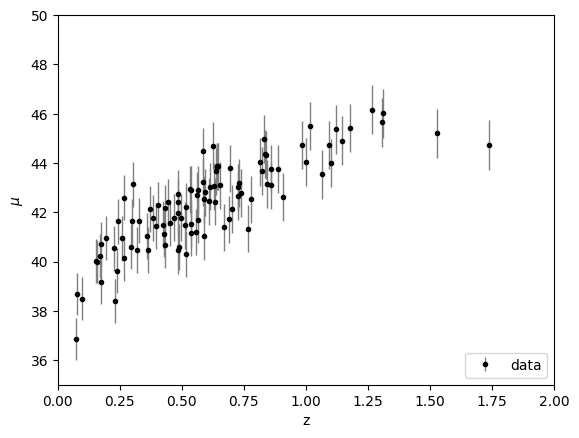

In [85]:
from astroML.datasets import generate_mu_z
import numpy as np
from matplotlib import pyplot as plt
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy
from sklearn.neighbors import KernelDensity
from scipy.stats import loguniform
from sklearn import datasets
from sklearn import manifold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from astropy.cosmology import LambdaCDM
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


### GPR

In [86]:
from sklearn.gaussian_process import GaussianProcessRegressor
z_sample_g = z_sample[:, np.newaxis]

#gpr assume that all the points follow a multivariate gaussian distribuition with a covariance given by a chosen kernel. Returns the predicted value with a given uncertainty

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) #constant kernel set global scale, RBF set the covariance between the points
gpr = GaussianProcessRegressor(kernel= kernel, alpha= (dmu)**2, n_restarts_optimizer=0, normalize_y=True, random_state=None)
gpr.fit(z_sample_g, mu_sample)
grid = np.linspace(0, z_sample_g.max(), 1000)
grid_test = grid[:, np.newaxis]
y_pred, dy_pred = gpr.predict(grid_test, return_std=True)
print(gpr.kernel_)

2.21**2 * RBF(length_scale=1.11)


Text(0.5, 1.0, 'GPR fit of $\\mu$ measurements')

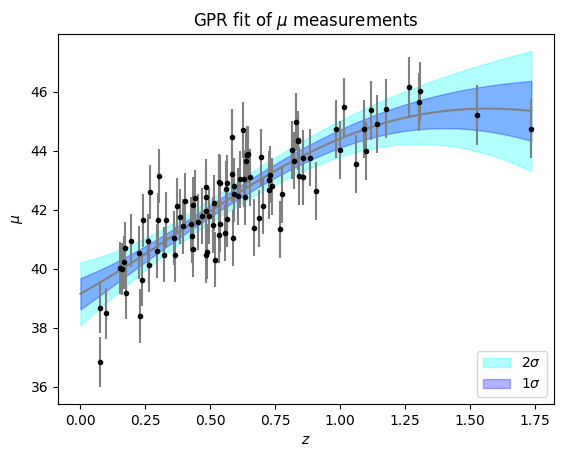

In [87]:
#GPR fit
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(grid, y_pred, '-', color='gray')
ax.fill_between(grid, y_pred - 2 * dy_pred, y_pred + 2 * dy_pred, 
                color='cyan', alpha=0.3, label = r"2$\sigma$")
ax.fill_between(grid, y_pred - 1 * dy_pred, y_pred + 1 * dy_pred, 
                color='blue', alpha=0.3, label = r"1$\sigma$")
ax.legend(loc='lower right')
ax.errorbar(z_sample_g, mu_sample, dmu, fmt='.k', ecolor='gray', ms=6)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r"$\mu$")
plt.title(r"GPR fit of $\mu$ measurements")

Now that we have fitted the data with GPR, we can predict new data with an associate uncertainty


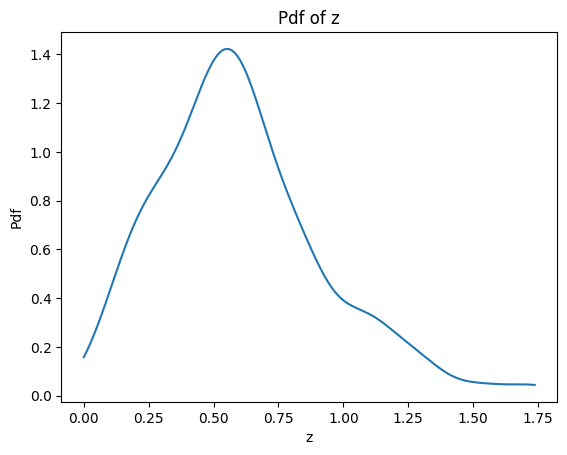

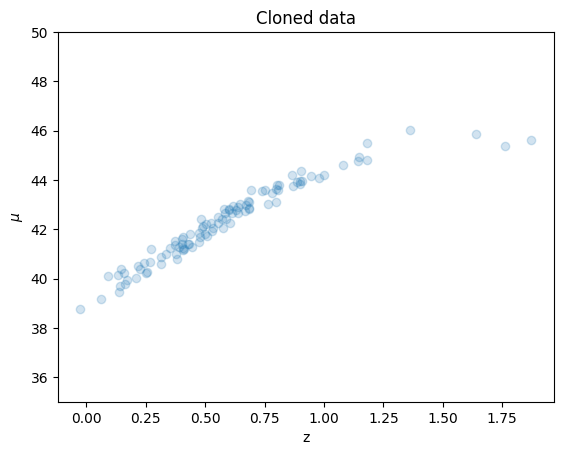

In [88]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.1)
kde.fit(z_sample_g)
log_pdf = kde.score_samples(grid_test)
pdf = np.exp(log_pdf)
plt.title("Pdf of z")
plt.plot(grid_test[:, 0], pdf)
plt.xlabel('z')
plt.ylabel('Pdf')
plt.show()

#sample from pdf
new_z = kde.sample(len(z_sample))

#generate new mu with gpr
mu_gpr=[]
for z in np.squeeze(new_z):    
    mu_fit, sigma_fit = gpr.predict([[z]], 
                           return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma_fit))
    
#New data plot    
plt.scatter(new_z,mu_gpr,alpha=0.2)
plt.xlabel("z")
plt.ylabel(r"$\mu$")

plt.ylim(35,50)
plt.title("Cloned data");


### MCMC

In [89]:
!pip install emcee
import emcee
import scipy.stats as scistats
import corner
import dynesty

Defaulting to user installation because normal site-packages is not writeable


In [90]:
def model(z, H0, Om):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value 

In [129]:
#setting a constant prior
def log_prior(theta):
    H0, Om = theta
    if (40 < H0 < 100) and (0.1 < Om < 1.05):
        return 0 
    else:
        return -np.inf

    
def log_likelihood(theta):
    H0,Om = theta
    mu_model = model(z_sample, H0, Om)
    return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample)) 
#return the loglikelihood of a normal distribuition located in mu_model with deviation dmu, evaluated in mu_sample

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

In [130]:

ndim = 2  # number of parameters in the model
nwalkers = 5  # at least 2×ndim walkers
 
nsteps = 10000  # number of MCMC steps for each walker

initial = np.array([80, 0.5])
starting_guesses = initial + 1e-1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(starting_guesses, nsteps, progress=True) 
tau = sampler.get_autocorr_time(tol = 0)

 
print(tau)
print(sampler.chain.shape) 

print("done")

100%|██████████| 10000/10000 [00:53<00:00, 187.32it/s]

[55.82596022 55.42012901]
(5, 10000, 2)
done


(10000, 5, 2)


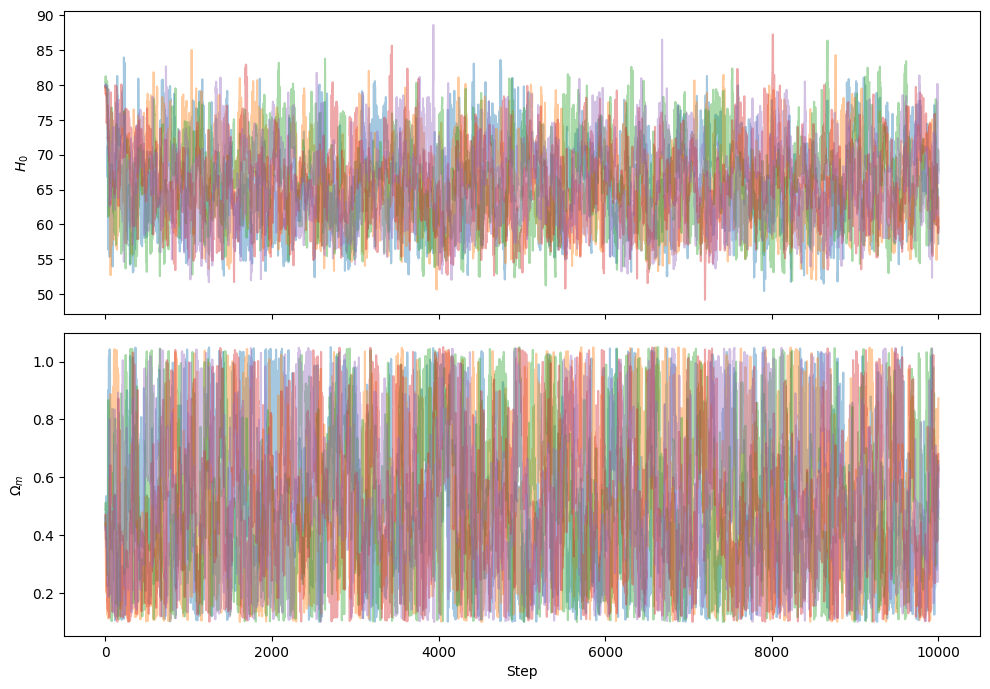

In [131]:
chains = sampler.get_chain()  # shape: (nsteps, nwalkers, ndim)
print(chains.shape)
nsteps, nwalkers, ndim = chains.shape
labels = [r'$H_{0}$', r'$\Omega_{m}$']

#Trace plots
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)

steps = np.arange(nsteps)
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(steps, chains[:, walker, i], alpha=0.4)
    ax.set_ylabel(labels[i])
    #ax.axvline(x=burn, color='red', linestyle='--')  # opzionale: linea burn-in

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()


In [132]:
#Remove burnin period and thin
flat_trace = sampler.get_chain(discard = 2* int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_trace.shape)

H0_median = np.median(flat_trace[:, 0])
Om_median = np.median(flat_trace[:,1])

(895, 2)


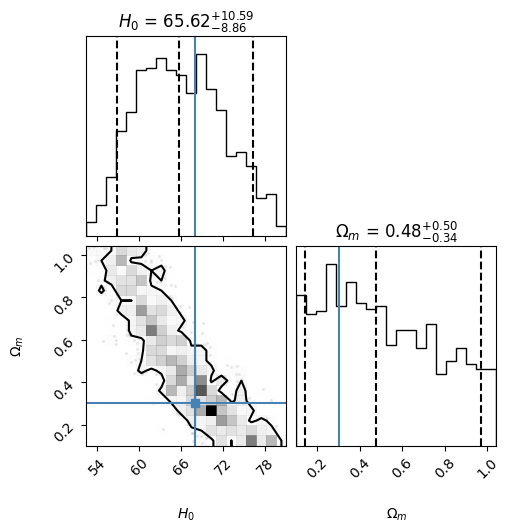

In [133]:
#Corner plot
fig = corner.corner(flat_trace, labels = labels, levels = [0.9], truths = [68, 0.3], quantiles = [0.05, 0.5, 0.95], show_titles = True, title_kwargs = {'fontsize':12})

From MCMC we get reasonable estimates of $H_{0}$ and $\Omega_{m}$.  
Now let's look at Nested sampling

### Nested sampling

In [96]:
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

In [134]:
#Defining uniform prior volume
def ptform(u):
    mins = np.array([30, 0.1]) #min of H0, Om
    maxs = np.array([100, 1.05]) #max H0, Om
    return mins + u * (maxs - mins)

In [135]:
sampler_d = dynesty.NestedSampler(log_likelihood, ptform, ndim) 
sampler_d.run_nested()
sresults = sampler_d.results

1706it [00:17, 100.10it/s, +500 | bound: 0 | nc: 1 | ncall: 15670 | eff(%): 14.542 | loglstar:   -inf < -132.815 <    inf | logz: -135.366 +/-  0.048 | dlogz:  0.001 >  0.509]


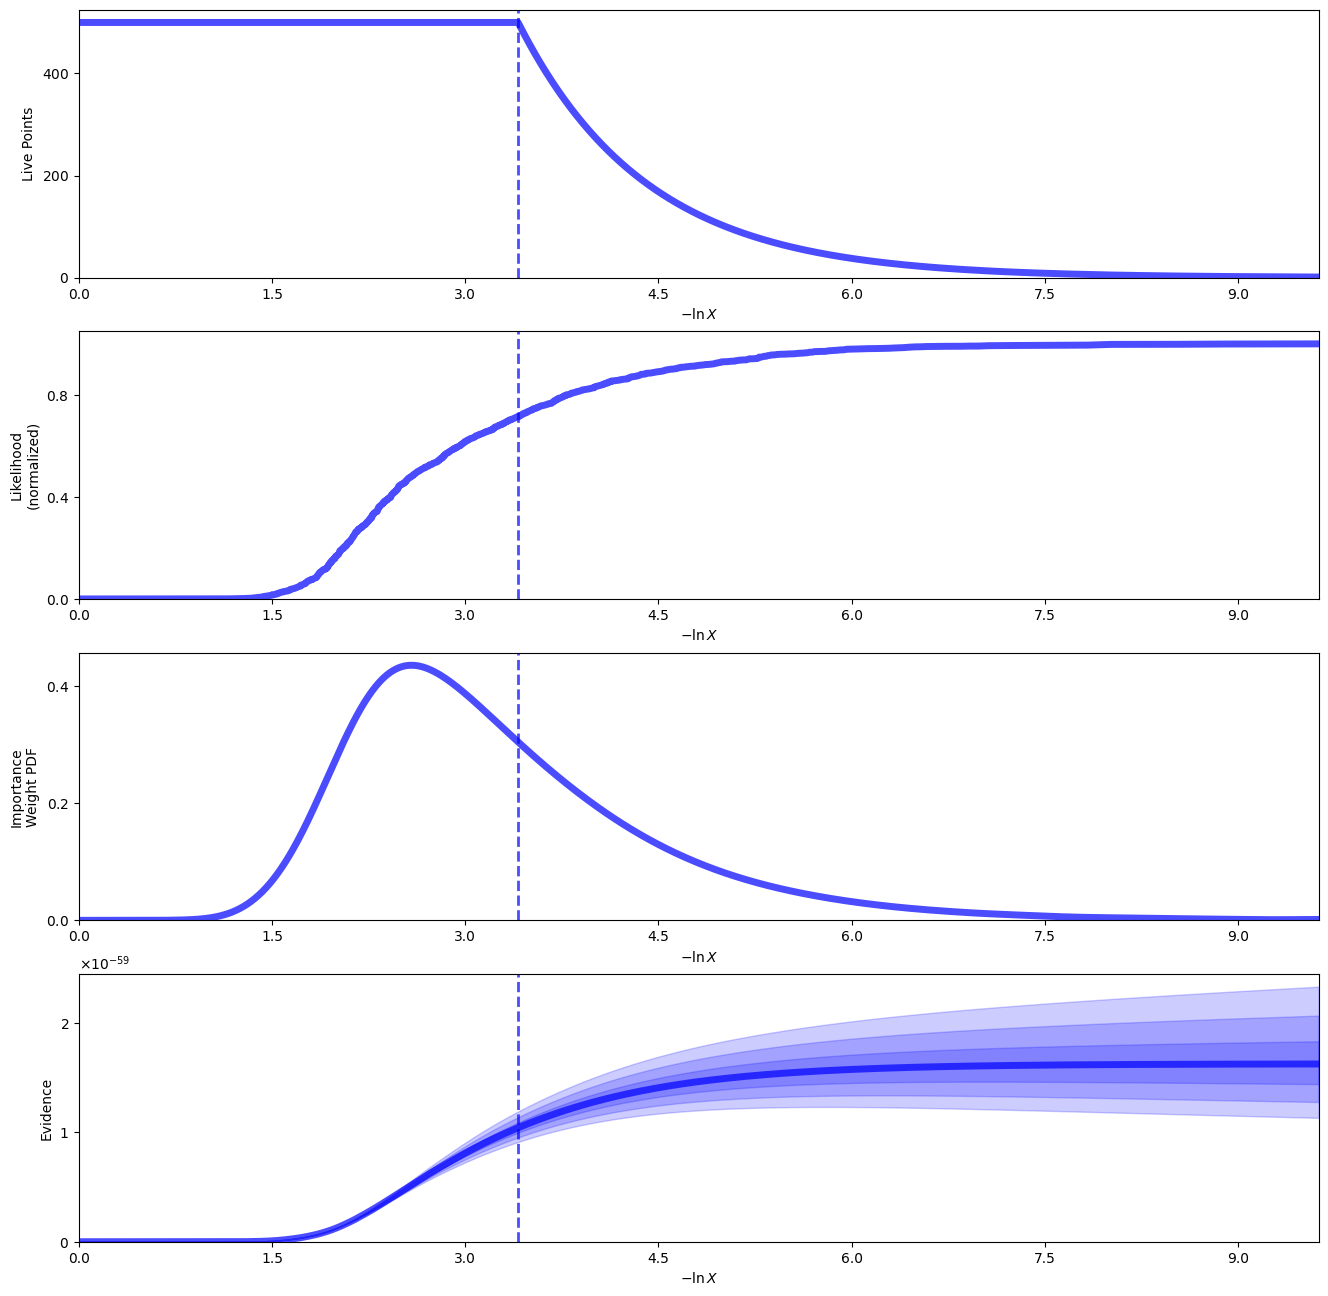

In [136]:
rfig, raxes = dyplot.runplot(sresults)

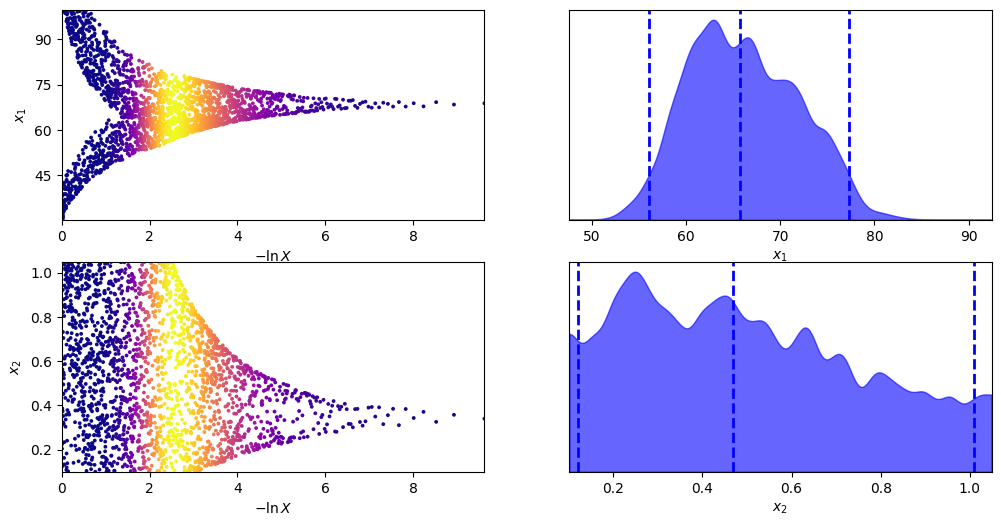

In [137]:
tfig, taxes = dyplot.traceplot(sresults)

68% parameter credible regions are:
 [[60.15548603204071, 72.39514001564626], [0.23040456938476206, 0.8001041613274077]]

Mean and covariance of parameters are: [66.07671783  0.50388252], [[33.35110581 -1.25079748]
 [-1.25079748  0.06450291]]


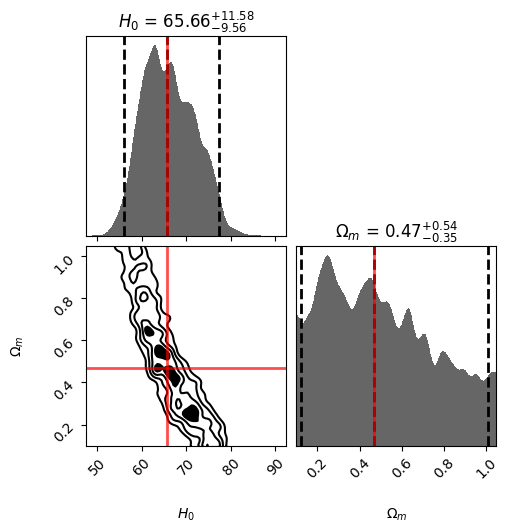

In [138]:
#Corner plot
samples = sresults.samples
weights = np.exp(sresults.logwt-sresults.logz[-1])
truths = [dyfunc.quantile(samps, 0.5, weights = weights) for samps in samples.T]

cfig, caxes = dyplot.cornerplot(sresults,truths=truths,
    show_titles=True,
    title_fmt=".2f",  
    labels=labels )
evidence = sresults.logz[-1]

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights = weights) for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(f'Mean and covariance of parameters are: {mean}, {cov}')
samples_equal = dyfunc.resample_equal(samples, weights)

Nested sampling estimate similar values for the parameters.

Let's plot the model with the optimal parameter over the data.

C:\Users\alexv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\astropy\cosmology\flrw\base.py:1351: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


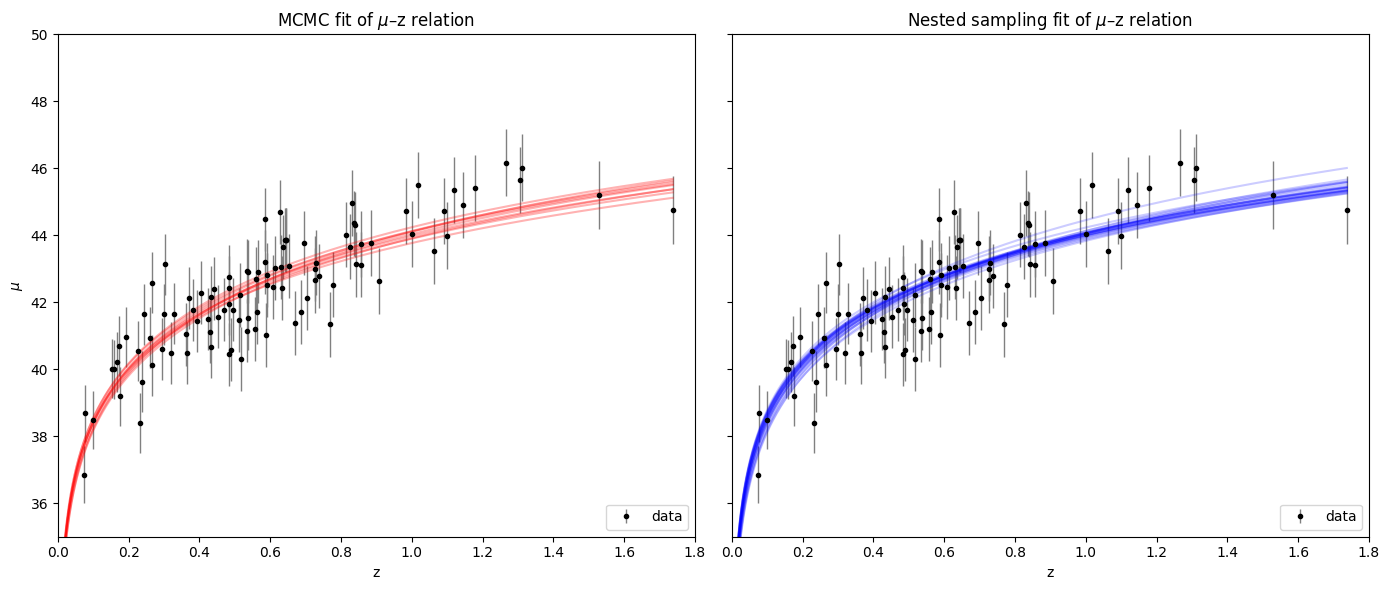

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

#  Plot MCMC
ax = axes[0]
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
for H0, Om in flat_trace[::100]:
    ax.plot(grid_test, model(grid_test, H0, Om), color='red', alpha=0.3)
ax.set_xlabel("z")
ax.set_ylabel(r"$\mu$")
ax.set_xlim(0, 1.8)
ax.set_ylim(35, 50)
ax.set_title(r"MCMC fit of $\mu$–z relation")
ax.legend(loc='lower right')

# Plot Nested Sampling
ax = axes[1]
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
for H0, Om in samples_equal[::100]:
    ax.plot(grid_test, model(grid_test, H0, Om), color='blue', alpha=0.2)
ax.set_xlabel("z")
ax.set_xlim(0, 1.8)
ax.set_ylim(35, 50)
ax.set_title(r"Nested sampling fit of $\mu$–z relation")
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Using MCMC and Nested sampling we have estimated the cosmological parameters $H_{0}$ and $\Omega_{m}$, which fit pretty well our dataset.
Moreover from the corner plots we can see that $H_{0}$ and $\Omega_{m}$ are anticorrelated.



### Fitting $\Omega_{\Lambda} = 0$, a Universe with no Dark Energy

In [140]:
#Defining prior volume
def ptform_m(u):
    mins = np.array([30])
    maxs = np.array([100])
    return mins + u * (maxs - mins)

#Matter dominated universe
def model_m(z, H0, Om = 1):
    cosmo_tmp_m = LambdaCDM(H0=H0, Om0=1, Ode0=1-Om)
    return cosmo_tmp_m.distmod(z).value 
    
def log_likelihood_m(theta_m):
    H0 = theta_m[0]
    Om = 1
    mu_model_m = model_m(z_sample, H0, Om)
    return np.sum(scistats.norm(loc=mu_model_m, scale=dmu).logpdf(mu_sample)) 

1712it [00:13, 128.79it/s, +500 | bound: 0 | nc: 1 | ncall: 13556 | eff(%): 16.942 | loglstar:   -inf < -133.530 <    inf | logz: -136.050 +/-  0.045 | dlogz:  0.001 >  0.509]


68% parameter credible regions are:
 [[55.10078947904995, 60.46999262971351]]

Mean and covariance of parameters are: [57.78768772], [[6.75933782]]


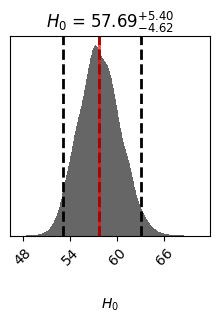

In [141]:
#Run nested sampler
ndim_m = 1
sampler_m = dynesty.NestedSampler(log_likelihood_m, ptform_m, ndim_m) 
sampler_m.run_nested()
sresults_m = sampler_m.results
samples_m = sresults_m.samples
weights_m = np.exp(sresults_m.logwt-sresults_m.logz[-1])
truths = [dyfunc.quantile(samps, 0.5, weights = weights_m) for samps in samples_m.T]

#corner plot
cfig, caxes = dyplot.cornerplot(sresults_m,truths=truths,
    show_titles=True,
    title_fmt=".2f",   
    labels=labels )

evidence_m = sresults.logz[-1]

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights = weights_m) for samps in samples_m.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples_m, weights_m)
print(f'Mean and covariance of parameters are: {mean}, {cov}')
samples_equal = dyfunc.resample_equal(samples_m, weights_m)

C:\Users\alexv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\astropy\cosmology\flrw\base.py:1351: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


(35.0, 50.0)

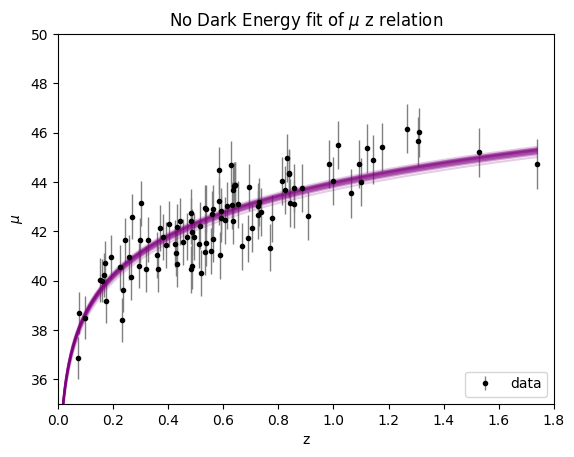

In [142]:
#Plot of No dark energy fit
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
for sample in samples_equal[::100]:
    H0 = sample[0]
    plt.plot(grid_test, model(grid_test, H0,Om = 1), color = 'purple', alpha = 0.2)
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,1.8)
plt.title(r"No Dark Energy fit of $\mu$ z relation")
plt.ylim(35,50)

In [143]:
bayes_factor = np.exp(sampler_d.results.logz[-1])/np.exp(sampler_m.results.logz[-1])
print(f"Bayes factor (No DE vs CDM,): {bayes_factor}")

Bayes factor (No DE vs CDM,): 1.982237163626294


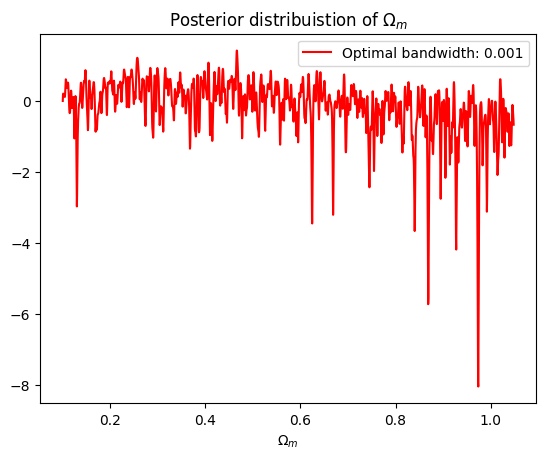

Savage-Dickey Bayes Factor: 2.42


In [145]:

#Savage Dickie ratio
from sklearn.model_selection import GridSearchCV
#Get Om samples from Broad model (Lambda CDM)
samples_equal = dyfunc.resample_equal(samples, weights)
Om_samples = samples_equal[:, 1]

# Posterior in lambda CDM
grid = np.linspace(np.min(Om_samples), np.max(Om_samples), len(Om_samples))
K = 5 #  5-fold cross validation
bw_range = np.linspace(0.001, 1, 100)
cv = GridSearchCV(KernelDensity(), {'bandwidth': bw_range}, cv= K) 

cv.fit(Om_samples[:, np.newaxis])
h_opt = cv.best_params_['bandwidth']
kde = KernelDensity(bandwidth = h_opt)
kde.fit(Om_samples[:, np.newaxis])

log_pdf = kde.score_samples(np.array([[0.99]])) #evaluate posterior density of broader model at the constrain (No DE, Om = 1)
posterior_constrain = np.exp(log_pdf[0])

# Prior density (uniform)
prior_constrain = 1 / (1.05 - 0.1)

pdf = kde.score_samples(grid[:, np.newaxis])
plt.plot(grid,pdf,c='red', label = f'Optimal bandwidth: {h_opt:.3f}')
plt.title(r"Posterior distribuistion of $\Omega_{m}$")
plt.xlabel(r"$\Omega_{m}$")
plt.legend()
plt.show()
# Savage-Dickey Bayes Factor
sddr = prior_constrain / posterior_constrain
print(f"Savage-Dickey Bayes Factor: {sddr:.2f}")

From the Savage dickie ratio and Bayes factor estimates, we have slight evidence that the data favour the $\Lambda CDM$ model.